<a href="https://colab.research.google.com/github/Kishown-e22194/Statistical-Learning-e22194/blob/main/Assignment%206:%20Gaussian%20Process%20Regression%20and%20Linear%20Regression%20.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Assignment 6: Gaussian Process Regression and Linear Regression

# E/22/194


# 1.

In [1]:
!pip install kagglehub datawash-inspector==0.1.1 -q

import os
import warnings
warnings.filterwarnings("ignore")

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datawash import DataPipeline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 52.8 MB/s eta 0:00:00


In [2]:
kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)
print("Files:")
!ls "$path"

df_raw = pd.read_csv(path + "/ENB2012_data.csv")
df_raw.head()

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset
Files:
ENB2012_data.csv


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [3]:
raw_csv_path = "energy_efficiency_raw.csv"
cleaned_csv_path = "energy_efficiency_cleaned.csv"

df_raw.to_csv(raw_csv_path, index=False)

pipe = DataPipeline()
pipe.load_data(raw_csv_path)

pipe.sanitize_garbage().auto_type_correct()
pipe.handle_missing_values(strategy="auto")

pipe.save_data(cleaned_csv_path)

df = pd.read_csv(cleaned_csv_path)

df.columns = df.columns.astype(str).str.strip()

print("Raw dataset shape:", df_raw.shape)
print("Cleaned dataset shape:", df.shape)

df.head()


Processing "energy_efficiency_raw.csv"...
INFO:datawash:
Processing "energy_efficiency_raw.csv"...
Success! Loaded dataset with 768 rows and 10 columns.
INFO:datawash:Success! Loaded dataset with 768 rows and 10 columns.
Sanitization complete: Garbage strings and pure whitespace converted to NaNs.
INFO:datawash:Sanitization complete: Garbage strings and pure whitespace converted to NaNs.
No columns required type conversion.
INFO:datawash:No columns required type conversion.

Imputation Strategy: 'auto'
INFO:datawash:
Imputation Strategy: 'auto'
Data saved to 'energy_efficiency_cleaned.csv' (csv).
INFO:datawash:Data saved to 'energy_efficiency_cleaned.csv' (csv).


Raw dataset shape: (768, 10)
Cleaned dataset shape: (768, 10)


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [4]:
feature_cols = ["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8"]
target_cols = ["Y1", "Y2"]

required_cols = feature_cols + target_cols

missing_cols = [col for col in required_cols if col not in df.columns]

if len(missing_cols) > 0:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df[required_cols].copy()

for col in required_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=required_cols).reset_index(drop=True)

X = df[feature_cols].values
y_heat = df["Y1"].values
y_cool = df["Y2"].values

print("Final dataset shape:", df.shape)
print("X shape:", X.shape)
print("Y1 shape:", y_heat.shape)
print("Y2 shape:", y_cool.shape)

display(df.describe())
display(df.head())

Final dataset shape: (768, 10)
X shape: (768, 8)
Y1 shape: (768,)
Y2 shape: (768,)


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


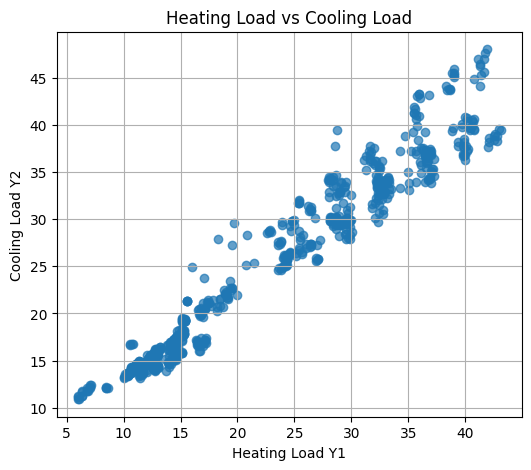

Correlation between Y1 and Y2: 0.9758618134328573


In [5]:
plt.figure(figsize=(6, 5))
plt.scatter(y_heat, y_cool, alpha=0.7)
plt.xlabel("Heating Load Y1")
plt.ylabel("Cooling Load Y2")
plt.title("Heating Load vs Cooling Load")
plt.grid(True)
plt.show()

print("Correlation between Y1 and Y2:", np.corrcoef(y_heat, y_cool)[0, 1])

In [6]:
X_train, X_test, y_heat_train, y_heat_test, y_cool_train, y_cool_test = train_test_split(
    X,
    y_heat,
    y_cool,
    test_size=0.25,
    random_state=42
)

x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

heat_scaler = StandardScaler()
cool_scaler = StandardScaler()

y_heat_train_scaled = heat_scaler.fit_transform(
    y_heat_train.reshape(-1, 1)
).ravel()

y_cool_train_scaled = cool_scaler.fit_transform(
    y_cool_train.reshape(-1, 1)
).ravel()

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_heat_train_scaled:", y_heat_train_scaled.shape)
print("y_cool_train_scaled:", y_cool_train_scaled.shape)

X_train_scaled: (576, 8)
X_test_scaled: (192, 8)
y_heat_train_scaled: (576,)
y_cool_train_scaled: (576,)


In [7]:
def train_full_gpr(X_train_scaled, X_test_scaled, y_train_scaled, y_test, y_scaler, target_name):
    d = X_train_scaled.shape[1]

    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * RBF(length_scale=np.ones(d), length_scale_bounds=(1e-2, 1e2))
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1e1))
    )

    model = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=False,
        n_restarts_optimizer=5,
        random_state=42
    )

    model.fit(X_train_scaled, y_train_scaled)

    y_pred_scaled, y_std_scaled = model.predict(
        X_test_scaled,
        return_std=True
    )

    y_pred = y_scaler.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).ravel()

    y_std = y_std_scaled * y_scaler.scale_[0]

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(target_name)
    print("Optimized kernel:", model.kernel_)
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)
    print()

    return model, y_pred, y_std, rmse, mae, r2

In [8]:
gpr_heat_full, y_heat_pred_full, y_heat_std_full, heat_rmse_full, heat_mae_full, heat_r2_full = train_full_gpr(
    X_train_scaled,
    X_test_scaled,
    y_heat_train_scaled,
    y_heat_test,
    heat_scaler,
    "Full 8-D GPR for Heating Load Y1"
)

gpr_cool_full, y_cool_pred_full, y_cool_std_full, cool_rmse_full, cool_mae_full, cool_r2_full = train_full_gpr(
    X_train_scaled,
    X_test_scaled,
    y_cool_train_scaled,
    y_cool_test,
    cool_scaler,
    "Full 8-D GPR for Cooling Load Y2"
)

Full 8-D GPR for Heating Load Y1
Optimized kernel: 2.22**2 * RBF(length_scale=[2.38, 100, 1.21, 100, 3.04, 100, 2.51, 100]) + WhiteKernel(noise_level=0.00202)
RMSE: 0.45458229618258045
MAE : 0.3397790821490048
R2  : 0.9980340103422038

Full 8-D GPR for Cooling Load Y2
Optimized kernel: 0.9**2 * RBF(length_scale=[0.664, 100, 0.841, 100, 0.3, 1.42, 7.76, 0.945]) + WhiteKernel(noise_level=0.00227)
RMSE: 0.6978023911114822
MAE : 0.4547819798792223
R2  : 0.9947846891154409



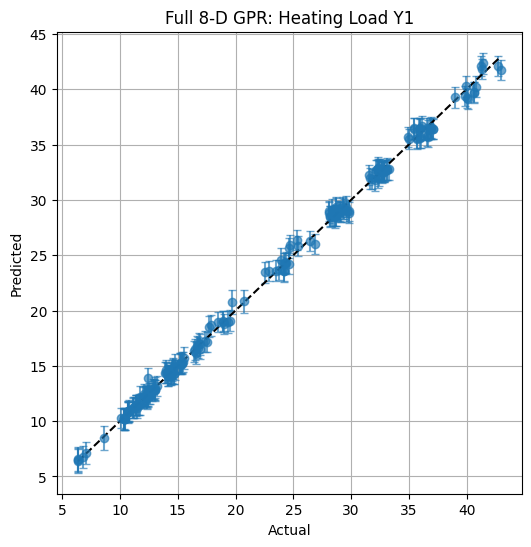

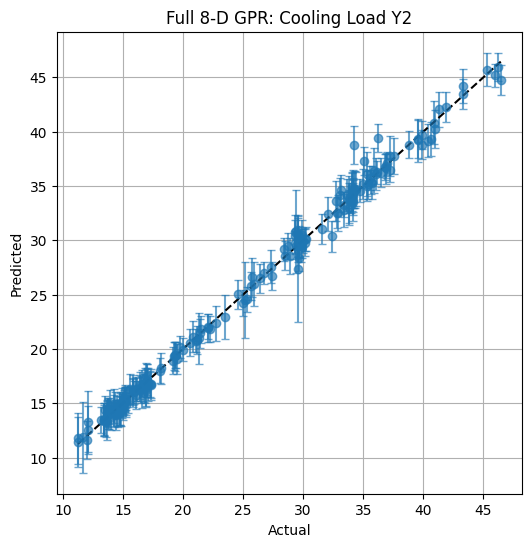

In [9]:
def plot_actual_vs_predicted(y_true, y_pred, y_std, title):
    plt.figure(figsize=(6, 6))

    plt.errorbar(
        y_true,
        y_pred,
        yerr=1.96 * y_std,
        fmt="o",
        alpha=0.65,
        capsize=3
    )

    min_value = min(np.min(y_true), np.min(y_pred))
    max_value = max(np.max(y_true), np.max(y_pred))

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        "k--"
    )

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.grid(True)
    plt.show()


plot_actual_vs_predicted(
    y_heat_test,
    y_heat_pred_full,
    y_heat_std_full,
    "Full 8-D GPR: Heating Load Y1"
)

plot_actual_vs_predicted(
    y_cool_test,
    y_cool_pred_full,
    y_cool_std_full,
    "Full 8-D GPR: Cooling Load Y2"
)

In [10]:
pca = PCA(n_components=1)

g_train = pca.fit_transform(X_train_scaled)
g_test = pca.transform(X_test_scaled)

print("g_train shape:", g_train.shape)
print("g_test shape:", g_test.shape)
print("PC1 explained variance ratio:", pca.explained_variance_ratio_[0])

g_train shape: (576, 1)
g_test shape: (192, 1)
PC1 explained variance ratio: 0.4635566690175483


In [11]:
def train_single_parameter_gpr(g_train, g_test, y_train_scaled, y_test, y_scaler, target_name):
    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1e1))
    )

    model = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=False,
        n_restarts_optimizer=5,
        random_state=42
    )

    model.fit(g_train, y_train_scaled)

    y_pred_scaled, y_std_scaled = model.predict(
        g_test,
        return_std=True
    )

    y_pred = y_scaler.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).ravel()

    y_std = y_std_scaled * y_scaler.scale_[0]

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(target_name)
    print("Optimized kernel:", model.kernel_)
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)
    print()

    return model, y_pred, y_std, rmse, mae, r2

In [12]:
gpr_heat_1d, y_heat_pred_1d, y_heat_std_1d, heat_rmse_1d, heat_mae_1d, heat_r2_1d = train_single_parameter_gpr(
    g_train,
    g_test,
    y_heat_train_scaled,
    y_heat_test,
    heat_scaler,
    "Single-Parameter GPR for Heating Load Y1"
)

gpr_cool_1d, y_cool_pred_1d, y_cool_std_1d, cool_rmse_1d, cool_mae_1d, cool_r2_1d = train_single_parameter_gpr(
    g_train,
    g_test,
    y_cool_train_scaled,
    y_cool_test,
    cool_scaler,
    "Single-Parameter GPR for Cooling Load Y2"
)

Single-Parameter GPR for Heating Load Y1
Optimized kernel: 0.922**2 * RBF(length_scale=0.288) + WhiteKernel(noise_level=0.0961)
RMSE: 3.144757518405125
MAE : 2.322091607743972
R2  : 0.9059128050366814

Single-Parameter GPR for Cooling Load Y2
Optimized kernel: 1.02**2 * RBF(length_scale=0.272) + WhiteKernel(noise_level=0.0812)
RMSE: 2.8850134182890788
MAE : 2.228054139088046
R2  : 0.9108521302060624



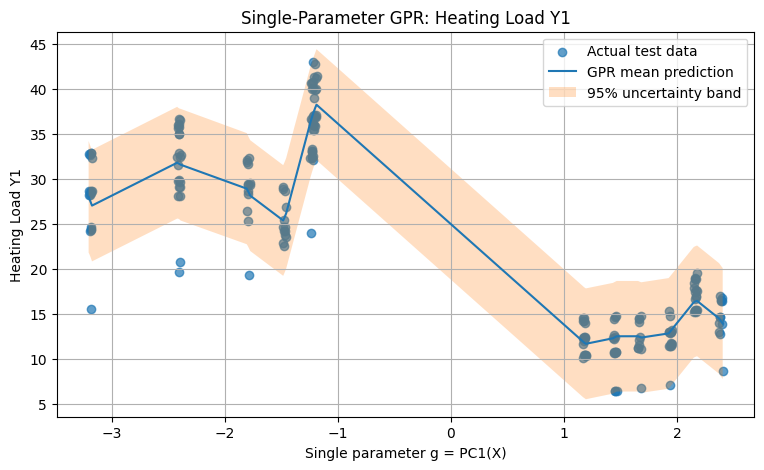

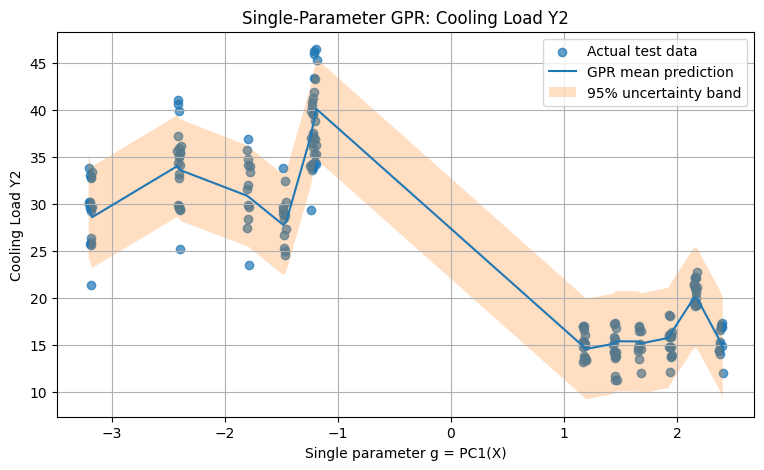

In [13]:
def plot_single_parameter_gpr(g_test, y_true, y_pred, y_std, title, ylabel):
    order = np.argsort(g_test.ravel())

    g_sorted = g_test.ravel()[order]
    y_true_sorted = y_true[order]
    y_pred_sorted = y_pred[order]
    y_std_sorted = y_std[order]

    lower = y_pred_sorted - 1.96 * y_std_sorted
    upper = y_pred_sorted + 1.96 * y_std_sorted

    plt.figure(figsize=(9, 5))

    plt.scatter(
        g_sorted,
        y_true_sorted,
        alpha=0.7,
        label="Actual test data"
    )

    plt.plot(
        g_sorted,
        y_pred_sorted,
        label="GPR mean prediction"
    )

    plt.fill_between(
        g_sorted,
        lower,
        upper,
        alpha=0.25,
        label="95% uncertainty band"
    )

    plt.xlabel("Single parameter g = PC1(X)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_single_parameter_gpr(
    g_test,
    y_heat_test,
    y_heat_pred_1d,
    y_heat_std_1d,
    "Single-Parameter GPR: Heating Load Y1",
    "Heating Load Y1"
)

plot_single_parameter_gpr(
    g_test,
    y_cool_test,
    y_cool_pred_1d,
    y_cool_std_1d,
    "Single-Parameter GPR: Cooling Load Y2",
    "Cooling Load Y2"
)

In [14]:
results = pd.DataFrame({
    "Model": [
        "Full 8-D GPR",
        "Full 8-D GPR",
        "Single-Parameter GPR",
        "Single-Parameter GPR"
    ],
    "Target": [
        "Heating Load Y1",
        "Cooling Load Y2",
        "Heating Load Y1",
        "Cooling Load Y2"
    ],
    "RMSE": [
        heat_rmse_full,
        cool_rmse_full,
        heat_rmse_1d,
        cool_rmse_1d
    ],
    "MAE": [
        heat_mae_full,
        cool_mae_full,
        heat_mae_1d,
        cool_mae_1d
    ],
    "R2": [
        heat_r2_full,
        cool_r2_full,
        heat_r2_1d,
        cool_r2_1d
    ]
})

display(results)

,Model,Target,RMSE,MAE,R2
0,Full 8-D GPR,Heating Load Y1,0.454582,0.339779,0.998034
1,Full 8-D GPR,Cooling Load Y2,0.697802,0.454782,0.994785
2,Single-Parameter GPR,Heating Load Y1,3.144758,2.322092,0.905913
3,Single-Parameter GPR,Cooling Load Y2,2.885013,2.228054,0.910852


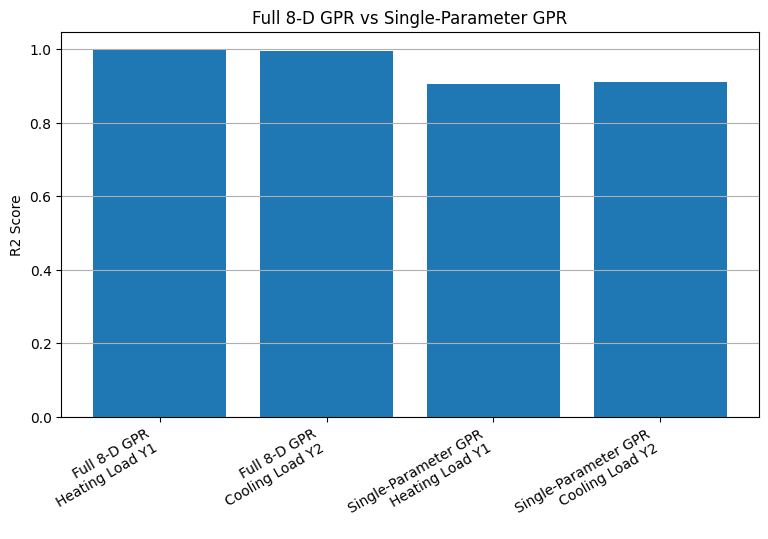

In [15]:
plt.figure(figsize=(9, 5))

labels = results["Model"] + "\n" + results["Target"]

plt.bar(labels, results["R2"])

plt.ylabel("R2 Score")
plt.title("Full 8-D GPR vs Single-Parameter GPR")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.show()

In [16]:
print("Final Decision")
print("==============")

print("\nHeating Load Y1:")
print("Full 8-D R2:", heat_r2_full)
print("Single-Parameter R2:", heat_r2_1d)

if heat_r2_1d >= heat_r2_full - 0.05:
    print("Y1 can be modeled reasonably well using a single-parameter Gaussian Process.")
else:
    print("Y1 loses important information in the single-parameter Gaussian Process.")

print("\nCooling Load Y2:")
print("Full 8-D R2:", cool_r2_full)
print("Single-Parameter R2:", cool_r2_1d)

if cool_r2_1d >= cool_r2_full - 0.05:
    print("Y2 can be modeled reasonably well using a single-parameter Gaussian Process.")
else:
    print("Y2 loses important information in the single-parameter Gaussian Process.")

Final Decision

Heating Load Y1:
Full 8-D R2: 0.9980340103422038
Single-Parameter R2: 0.9059128050366814
Y1 loses important information in the single-parameter Gaussian Process.

Cooling Load Y2:
Full 8-D R2: 0.9947846891154409
Single-Parameter R2: 0.9108521302060624
Y2 loses important information in the single-parameter Gaussian Process.


# 2.

In [17]:

# Install and import libraries


!pip install kagglehub datawash-inspector==0.1.1 -q

import os
import warnings
warnings.filterwarnings("ignore")

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [18]:

# Download and load the dataset


kagglepath = "programmer3/green-building-multi-source-environment-dataset"

path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

print(f"Listing contents of: {path}")
!ls "$path"

df_raw = pd.read_csv(path + "/green_building_dataset.csv")

print("Raw dataset shape:", df_raw.shape)
df_raw.head()

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset
Listing contents of: /kaggle/input/green-building-multi-source-environment-dataset
green_building_dataset.csv
Raw dataset shape: (2400, 19)


,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000


In [19]:

# Clean the dataset using my own data cleaning library datawash-inspector


from datawash import DataPipeline

raw_csv_path = "green_building_raw.csv"
cleaned_csv_path = "green_building_cleaned.csv"

df_raw.to_csv(raw_csv_path, index=False)

try:
    pipe = DataPipeline()
    pipe.load_data(raw_csv_path)

    if hasattr(pipe, "sanitize_garbage"):
        pipe.sanitize_garbage()

    if hasattr(pipe, "auto_type_correct"):
        pipe.auto_type_correct()

    if hasattr(pipe, "handle_missing_values"):
        try:
            pipe.handle_missing_values(strategy="auto")
        except TypeError:
            pipe.handle_missing_values()

    if hasattr(pipe, "save_data"):
        pipe.save_data(cleaned_csv_path)
        df = pd.read_csv(cleaned_csv_path)
    else:
        df = df_raw.copy()

    print("Cleaning completed using datawash-inspector.")

except Exception as e:
    print("datawash-inspector cleaning failed, using fallback pandas cleaning.")
    print("Error:", e)
    df = df_raw.copy()

df.columns = df.columns.astype(str).str.strip()

print("Cleaned dataset shape:", df.shape)
df.head()


Processing "green_building_raw.csv"...
INFO:datawash:
Processing "green_building_raw.csv"...
Success! Loaded dataset with 2400 rows and 19 columns.
INFO:datawash:Success! Loaded dataset with 2400 rows and 19 columns.
Sanitization complete: Garbage strings and pure whitespace converted to NaNs.
INFO:datawash:Sanitization complete: Garbage strings and pure whitespace converted to NaNs.
No columns required type conversion.
INFO:datawash:No columns required type conversion.

Imputation Strategy: 'auto'
INFO:datawash:
Imputation Strategy: 'auto'
Data saved to 'green_building_cleaned.csv' (csv).
INFO:datawash:Data saved to 'green_building_cleaned.csv' (csv).


Cleaning completed using datawash-inspector.
Cleaned dataset shape: (2400, 19)


,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000


In [20]:

# Basic dataset checking


print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
display(df.info())

print("\nMissing values:")
display(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe(include="all"))

Column names:
['indoor_temperature', 'indoor_humidity', 'co2_concentration', 'indoor_lighting', 'indoor_noise', 'outdoor_temperature', 'outdoor_humidity', 'solar_radiation', 'wind_speed', 'rainfall', 'electricity_consumption', 'heating_energy', 'cooling_energy', 'ventilation_rate', 'equipment_load', 'occupancy', 'activity_level', 'predicted_energy_demand', 'predicted_comfort_index']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   indoor_temperature       2400 non-null   float64
 1   indoor_humidity          2400 non-null   float64
 2   co2_concentration        2400 non-null   float64
 3   indoor_lighting          2400 non-null   float64
 4   indoor_noise             2400 non-null   float64
 5   outdoor_temperature      2400 non-null   float64
 6   outdoor_humidity         2400 non-null   float64

None


Missing values:


,0
indoor_temperature,0
indoor_humidity,0
co2_concentration,0
indoor_lighting,0
indoor_noise,0
outdoor_temperature,0
outdoor_humidity,0
solar_radiation,0
wind_speed,0
rainfall,0



Summary statistics:


,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,23.983870,49.790705,1170.150558,537.938849,55.157072,17.297311,55.186854,512.313662,7.615605,25.774823,24.796787,19.557364,24.980710,249.322350,14.839245,24.863333,1.503750,33.724789,0.001330
std,3.494409,11.514037,476.676518,254.252073,14.537491,13.163134,20.086905,286.687214,4.346765,14.407992,14.229819,11.461431,14.405205,144.429508,8.620437,14.537201,1.126061,9.560419,0.012970
min,18.018781,30.000465,350.397658,100.047544,30.007887,-4.945837,20.017672,0.611635,0.014985,0.002406,0.005512,0.005006,0.003375,0.199846,0.000166,0.000000,0.000000,1.831555,0.000000
25%,20.900275,39.940031,753.792246,325.956124,42.558186,5.647292,37.982148,268.639365,3.909123,13.733789,12.651079,9.458481,12.813325,122.670289,7.255240,12.750000,0.000000,27.114764,0.000000
50%,24.089278,49.697217,1156.849445,532.777499,55.088203,16.964253,55.392092,519.415412,7.667388,25.807678,24.760944,19.643330,25.090347,251.389623,14.872126,25.000000,2.000000,33.577877,0.000000
75%,26.988393,59.681864,1592.308520,747.543049,67.975269,29.046823,72.630587,753.235164,11.313872,38.342784,36.686875,29.188313,37.667744,369.692475,22.170251,37.000000,3.000000,40.417122,0.000000
max,29.996612,69.982308,1999.110124,999.014230,79.983660,39.948017,89.994738,999.871438,14.998515,49.982815,49.972526,39.987824,49.986604,499.848605,29.993681,50.000000,3.000000,58.721555,0.234932


In [21]:

# Select target variable and numeric candidate parameters

target_col = "predicted_energy_demand"

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' was not found. Available columns are: {df.columns.tolist()}")

df_model = df.copy()

for col in df_model.columns:
    df_model[col] = pd.to_numeric(df_model[col], errors="ignore")

numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()

if target_col not in numeric_cols:
    df_model[target_col] = pd.to_numeric(df_model[target_col], errors="coerce")
    numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()

candidate_features = [col for col in numeric_cols if col != target_col]

df_model = df_model[candidate_features + [target_col]].copy()
df_model = df_model.dropna().reset_index(drop=True)

print("Target variable:")
print(target_col)

print("\nNumber of candidate numeric features:", len(candidate_features))
print(candidate_features)

print("\nFinal modeling dataset shape:", df_model.shape)
df_model.head()

Target variable:
predicted_energy_demand

Number of candidate numeric features: 18
['indoor_temperature', 'indoor_humidity', 'co2_concentration', 'indoor_lighting', 'indoor_noise', 'outdoor_temperature', 'outdoor_humidity', 'solar_radiation', 'wind_speed', 'rainfall', 'electricity_consumption', 'heating_energy', 'cooling_energy', 'ventilation_rate', 'equipment_load', 'occupancy', 'activity_level', 'predicted_comfort_index']

Final modeling dataset shape: (2400, 19)


,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_comfort_index,predicted_energy_demand
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,0.234932,39.936909
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,0.000000,24.985061
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,0.000000,39.675344
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,0.000000,52.678350
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,0.000000,48.824527


In [22]:

# Choose suitable parameters using correlation


corr_with_target = df_model.corr(numeric_only=True)[target_col].drop(target_col)
corr_abs = corr_with_target.abs().sort_values(ascending=False)

corr_table = pd.DataFrame({
    "Feature": corr_abs.index,
    "Correlation_with_target": corr_with_target[corr_abs.index].values,
    "Absolute_correlation": corr_abs.values
})

display(corr_table)

correlation_threshold = 0.10

selected_features = corr_abs[corr_abs >= correlation_threshold].index.tolist()

if len(selected_features) == 0:
    selected_features = corr_abs.head(8).index.tolist()

print("Selected suitable parameters:")
print(selected_features)

,Feature,Correlation_with_target,Absolute_correlation
0,ventilation_rate,0.728865,0.728865
1,electricity_consumption,0.398703,0.398703
2,cooling_energy,0.370632,0.370632
3,heating_energy,0.271304,0.271304
4,equipment_load,0.058766,0.058766
5,occupancy,0.057655,0.057655
6,co2_concentration,-0.036466,0.036466
7,indoor_noise,-0.024454,0.024454
8,indoor_lighting,-0.020631,0.020631
9,activity_level,0.018522,0.018522


Selected suitable parameters:
['ventilation_rate', 'electricity_consumption', 'cooling_energy', 'heating_energy']


In [23]:

# Prepare X and y


X = df_model[selected_features].values
y = df_model[target_col].values

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nSelected feature names:")
print(selected_features)

X shape: (2400, 4)
y shape: (2400,)

Selected feature names:
['ventilation_rate', 'electricity_consumption', 'cooling_energy', 'heating_energy']


In [25]:

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1800
Testing samples: 600


In [26]:

# Scale input features


x_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

print("Mean of scaled training features:")
print(np.round(X_train_scaled.mean(axis=0), 4))

print("\nStandard deviation of scaled training features:")
print(np.round(X_train_scaled.std(axis=0), 4))

Mean of scaled training features:
[ 0. -0. -0.  0.]

Standard deviation of scaled training features:
[1. 1. 1. 1.]


In [27]:

# Train Linear Regression model

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_lr = linear_model.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("=========================")
print("RMSE:", rmse_lr)
print("MAE :", mae_lr)
print("R2  :", r2_lr)

Linear Regression Results
RMSE: 2.2359338508119846
MAE : 1.756721145616814
R2  : 0.9468458257819616


In [28]:

# Train Ridge Regression for comparison


ridge_model = RidgeCV(alphas=np.logspace(-4, 4, 50))

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("========================")
print("Best alpha:", ridge_model.alpha_)
print("RMSE:", rmse_ridge)
print("MAE :", mae_ridge)
print("R2  :", r2_ridge)

Ridge Regression Results
Best alpha: 0.18420699693267145
RMSE: 2.236010417938289
MAE : 1.7567944484127216
R2  : 0.9468421853056985


In [29]:

# Compare Linear Regression and Ridge Regression


results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "RMSE": [rmse_lr, rmse_ridge],
    "MAE": [mae_lr, mae_ridge],
    "R2": [r2_lr, r2_ridge]
})

display(results)

,Model,RMSE,MAE,R2
0,Linear Regression,2.235934,1.756721,0.946846
1,Ridge Regression,2.236010,1.756794,0.946842


In [30]:

# Compare Linear Regression and Ridge Regression


results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "RMSE": [rmse_lr, rmse_ridge],
    "MAE": [mae_lr, mae_ridge],
    "R2": [r2_lr, r2_ridge]
})

display(results)

,Model,RMSE,MAE,R2
0,Linear Regression,2.235934,1.756721,0.946846
1,Ridge Regression,2.236010,1.756794,0.946842


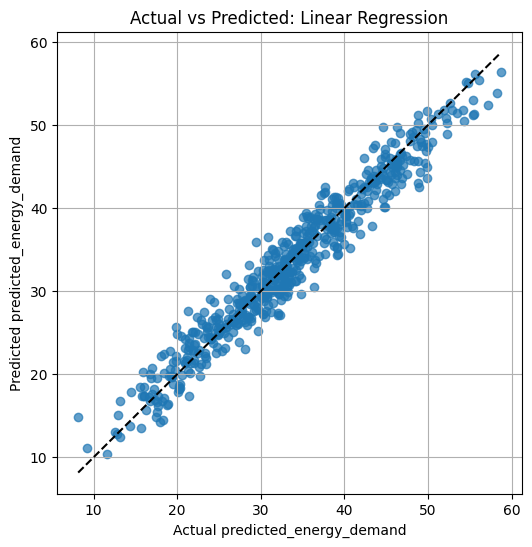

In [31]:

# Plot actual vs predicted values

best_model_name = "Ridge Regression" if r2_ridge > r2_lr else "Linear Regression"
best_pred = y_pred_ridge if r2_ridge > r2_lr else y_pred_lr

plt.figure(figsize=(6, 6))

plt.scatter(y_test, best_pred, alpha=0.7)

min_value = min(np.min(y_test), np.min(best_pred))
max_value = max(np.max(y_test), np.max(best_pred))

plt.plot([min_value, max_value], [min_value, max_value], "k--")

plt.xlabel("Actual predicted_energy_demand")
plt.ylabel("Predicted predicted_energy_demand")
plt.title(f"Actual vs Predicted: {best_model_name}")
plt.grid(True)
plt.show()

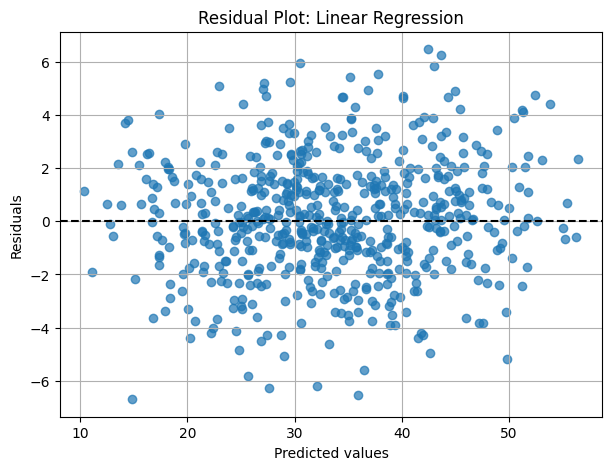

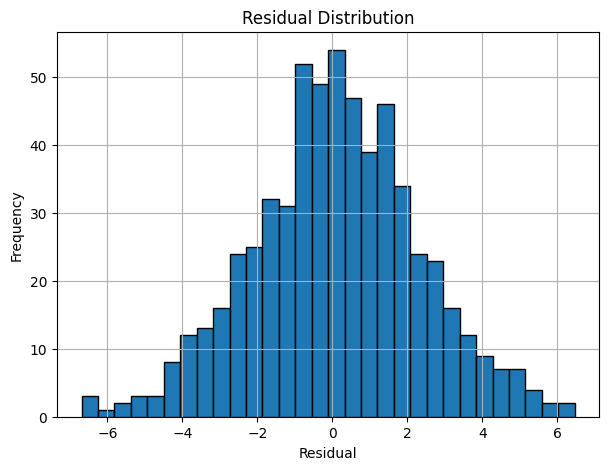

In [32]:

# Plot residuals

residuals = y_test - best_pred

plt.figure(figsize=(7, 5))

plt.scatter(best_pred, residuals, alpha=0.7)
plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot: {best_model_name}")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=30, edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.grid(True)
plt.show()

In [33]:

# Show regression equation coefficients


best_model = ridge_model if r2_ridge > r2_lr else linear_model

coef_table = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient_after_scaling": best_model.coef_
})

coef_table["Absolute_coefficient"] = coef_table["Coefficient_after_scaling"].abs()
coef_table = coef_table.sort_values("Absolute_coefficient", ascending=False)

display(coef_table)

intercept = best_model.intercept_

print("Best model:", best_model_name)
print("Intercept:", intercept)

print("\nLinear model form:")
print("predicted_energy_demand = beta_0 + beta_1*x_1 + beta_2*x_2 + ... + beta_p*x_p")

,Feature,Coefficient_after_scaling,Absolute_coefficient
0,ventilation_rate,7.123973,7.123973
1,electricity_consumption,4.157524,4.157524
2,cooling_energy,3.538213,3.538213
3,heating_energy,2.809038,2.809038


Best model: Linear Regression
Intercept: 33.80357938252397

Linear model form:
predicted_energy_demand = beta_0 + beta_1*x_1 + beta_2*x_2 + ... + beta_p*x_p


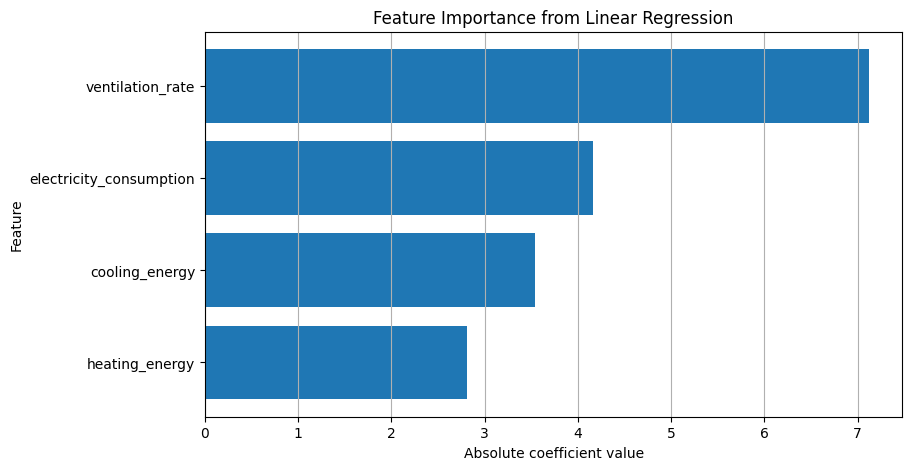

In [34]:

#  Plot feature importance using coefficient magnitude


plt.figure(figsize=(9, 5))

plt.barh(
    coef_table["Feature"],
    coef_table["Absolute_coefficient"]
)

plt.xlabel("Absolute coefficient value")
plt.ylabel("Feature")
plt.title(f"Feature Importance from {best_model_name}")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

In [35]:

# Cell 17: Final conclusion

best_rmse = rmse_ridge if r2_ridge > r2_lr else rmse_lr
best_mae = mae_ridge if r2_ridge > r2_lr else mae_lr
best_r2 = r2_ridge if r2_ridge > r2_lr else r2_lr

print("Final Answer")
print("============")
print()
print("Target variable:")
print(target_col)
print()
print("Selected suitable parameters:")
for f in selected_features:
    print("-", f)

print()
print("Best linear model:")
print(best_model_name)

print()
print("Performance:")
print("RMSE:", best_rmse)
print("MAE :", best_mae)
print("R2  :", best_r2)

print()
print("Conclusion:")

if best_r2 >= 0.80:
    print("The selected parameters provide a strong linear relationship for predicting predicted_energy_demand.")
elif best_r2 >= 0.60:
    print("The selected parameters provide a moderate linear relationship for predicting predicted_energy_demand.")
else:
    print("The selected parameters do not provide a strong linear relationship. A nonlinear model may be better.")

print()
print("Regression equation:")
print("predicted_energy_demand = beta_0 + beta_1*x_1 + beta_2*x_2 + ... + beta_p*x_p")

Final Answer

Target variable:
predicted_energy_demand

Selected suitable parameters:
- ventilation_rate
- electricity_consumption
- cooling_energy
- heating_energy

Best linear model:
Linear Regression

Performance:
RMSE: 2.2359338508119846
MAE : 1.756721145616814
R2  : 0.9468458257819616

Conclusion:
The selected parameters provide a strong linear relationship for predicting predicted_energy_demand.

Regression equation:
predicted_energy_demand = beta_0 + beta_1*x_1 + beta_2*x_2 + ... + beta_p*x_p
